In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
%matplotlib inline

In [3]:
df = pd.read_excel('Online Retail.xlsx', sheet_name='Online Retail')

In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
# checking the number of cancelled orders
df.loc[df['Quantity'] <= 0].shape

(10624, 8)

In [7]:
# dropping the cancelled orders
df = df.loc[df['Quantity'] > 0]

In [8]:
df['CustomerID'].isnull().value_counts()

CustomerID
False    397924
True     133361
Name: count, dtype: int64

In [9]:
df = df[pd.notnull(df['CustomerID'])]

In [10]:
print('Date Range: %s ~ %s' % (df['InvoiceDate'].min(), df['InvoiceDate'].max()))

Date Range: 2010-12-01 08:26:00 ~ 2011-12-09 12:50:00


In [11]:
df = df.loc[df['InvoiceDate']  < '2011-12-01']

In [12]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [13]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
customer_df = df.groupby('CustomerID').agg({
    'Sales': 'sum',
    'InvoiceNo': 'nunique'
})

In [15]:
customer_df.columns = ['TotalSales', 'OrderCount']
customer_df.head(3)

,TotalSales,OrderCount
CustomerID,,
12346.0,77183.60,1
12347.0,4085.18,6
12348.0,1797.24,4


In [16]:
# calculating average order value
customer_df['AvgOrderValue'] = customer_df['TotalSales']/customer_df['OrderCount']
customer_df.head(3)

,TotalSales,OrderCount,AvgOrderValue
CustomerID,,,
12346.0,77183.60,1,77183.600000
12347.0,4085.18,6,680.863333
12348.0,1797.24,4,449.310000


In [17]:
customer_df.describe()

,TotalSales,OrderCount,AvgOrderValue
count,4298.000000,4298.000000,4298.000000
mean,1952.818779,4.131689,400.255621
std,8354.913254,7.420253,1271.187289
min,0.000000,1.000000,0.000000
25%,304.305000,1.000000,178.602500
50%,657.265000,2.000000,295.033958
75%,1599.515000,4.000000,431.594250
max,268478.000000,201.000000,77183.600000


In [18]:
rank_df = customer_df.rank(method='first')

In [19]:
rank_df.head()

,TotalSales,OrderCount,AvgOrderValue
CustomerID,,,
12346.0,4290.0,1.0,4298.0
12347.0,3958.0,3470.0,3888.0
12348.0,3350.0,2861.0,3303.0
12349.0,3321.0,2.0,4238.0
12350.0,1241.0,3.0,2561.0


In [20]:
normalized_df = (rank_df - rank_df.mean()) / rank_df.std()

In [21]:
normalized_df.head()

,TotalSales,OrderCount,AvgOrderValue
CustomerID,,,
12346.0,1.724999,-1.731446,1.731446
12347.0,1.457445,1.064173,1.401033
12348.0,0.967466,0.573388,0.929590
12349.0,0.944096,-1.730641,1.683093
12350.0,-0.732148,-1.729835,0.331622


In [22]:
# installing machine learning  library
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [23]:
from sklearn.cluster import KMeans

In [35]:
from sklearn.metrics import silhouette_score

In [36]:
# selecting the best number of clusters
for n_cluster in [2,3,4,5,6,7,8]:
    kmeans = KMeans(n_clusters=n_cluster).fit(
        normalized_df[['TotalSales', 'OrderCount', 'AvgOrderValue']]
    )
    silhouette_avg = silhouette_score(
        normalized_df[['TotalSales', 'OrderCount', 'AvgOrderValue']],
        kmeans.labels_
    )

    print('Silhouette Score for %i Clusters: %0.4f' % (n_cluster, silhouette_avg))

Silhouette Score for 2 Clusters: 0.4285
Silhouette Score for 3 Clusters: 0.3651
Silhouette Score for 4 Clusters: 0.4100
Silhouette Score for 5 Clusters: 0.3771
Silhouette Score for 6 Clusters: 0.3690
Silhouette Score for 7 Clusters: 0.3726
Silhouette Score for 8 Clusters: 0.3811


In [43]:
kmeans = KMeans(n_clusters=4).fit(normalized_df[['TotalSales', 'OrderCount', 'AvgOrderValue']])

In [44]:
kmeans.labels_

array([0, 3, 3, ..., 2, 1, 3], shape=(4298,), dtype=int32)

In [45]:
kmeans.cluster_centers_

array([[-0.16044419, -0.85567505,  0.76388977],
       [ 0.33432183,  0.81308401, -0.60715659],
       [-1.21409232, -0.75468823, -1.05466576],
       [ 1.20261092,  0.96004509,  0.94134735]])

In [46]:
four_cluster_df = normalized_df.copy(deep=True)

In [47]:
four_cluster_df.head(2)

,TotalSales,OrderCount,AvgOrderValue
CustomerID,,,
12346.0,1.724999,-1.731446,1.731446
12347.0,1.457445,1.064173,1.401033


In [48]:
four_cluster_df['Cluster'] = kmeans.labels_

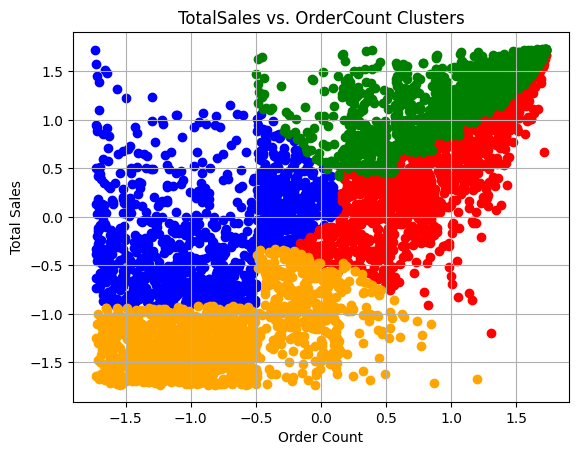

In [49]:
# OrderCount vs. Total Sales
plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 0]['OrderCount'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 0]['TotalSales'],
    c='blue')

plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 1]['OrderCount'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 1]['TotalSales'],
    c='red')

plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 2]['OrderCount'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 2]['TotalSales'],
    c='orange')

plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 3]['OrderCount'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 3]['TotalSales'],
    c='green')

plt.title('TotalSales vs. OrderCount Clusters')
plt.xlabel('Order Count')
plt.ylabel('Total Sales')

plt.grid()
plt.show()

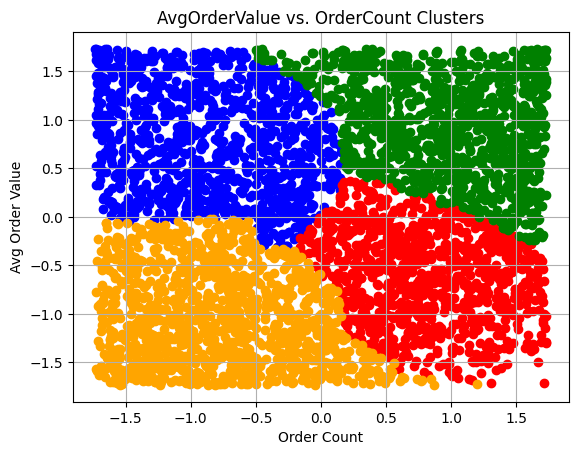

In [50]:
# OrderCount vs. Average Order Value
plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 0]['OrderCount'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 0]['AvgOrderValue'],
    c='blue')

plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 1]['OrderCount'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 1]['AvgOrderValue'],
    c='red')

plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 2]['OrderCount'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 2]['AvgOrderValue'],
    c='orange')

plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 3]['OrderCount'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 3]['AvgOrderValue'],
    c='green')

plt.title('AvgOrderValue vs. OrderCount Clusters')
plt.xlabel('Order Count')
plt.ylabel('Avg Order Value')

plt.grid()
plt.show()

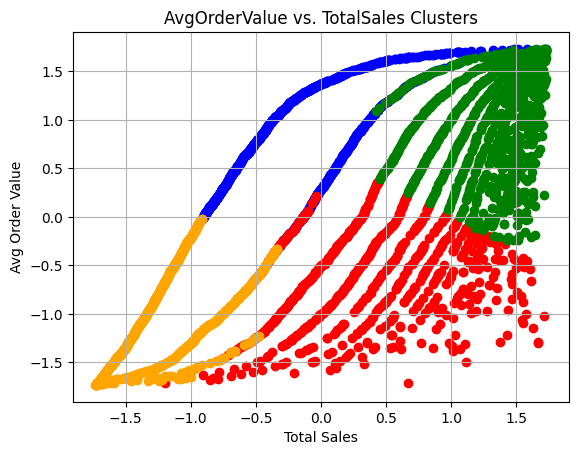

In [51]:
# Average Order Value vs. Total Sales
plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 0]['TotalSales'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 0]['AvgOrderValue'],
    c='blue')

plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 1]['TotalSales'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 1]['AvgOrderValue'],
    c='red')

plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 2]['TotalSales'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 2]['AvgOrderValue'],
    c='orange')

plt.scatter(
    four_cluster_df.loc[four_cluster_df['Cluster'] == 3]['TotalSales'],
    four_cluster_df.loc[four_cluster_df['Cluster'] == 3]['AvgOrderValue'],
    c='green')

plt.title('AvgOrderValue vs. TotalSales Clusters')
plt.xlabel('Total Sales')
plt.ylabel('Avg Order Value')

plt.grid()
plt.show()

In [52]:
# pareto analysis
pareto_df = customer_df.copy(deep=True)
pareto_df['Cluster']=kmeans.labels_

In [53]:
pareto_df = pareto_df[['Cluster', 'TotalSales']]

In [54]:
pareto_df = pareto_df.groupby('Cluster')['TotalSales'].sum().reset_index()
pareto_df

,Cluster,TotalSales
0,0,781275.731
1,1,1125717.812
2,2,240819.900
3,3,6245401.671


In [55]:
normalized_df['Cluster'] = kmeans.labels_

In [58]:
normalized_df['Cluster'].value_counts()

Cluster
2    1200
3    1092
0    1063
1     943
Name: count, dtype: int64

In [59]:
pareto_df = pareto_df.sort_values(by='TotalSales', ascending=False)

In [60]:
pareto_df['Cumulative Percentage'] = pareto_df['TotalSales'].cumsum() / pareto_df['TotalSales'].sum() * 100

In [62]:
pareto_df['Cluster'] = pareto_df['Cluster'].astype(str)

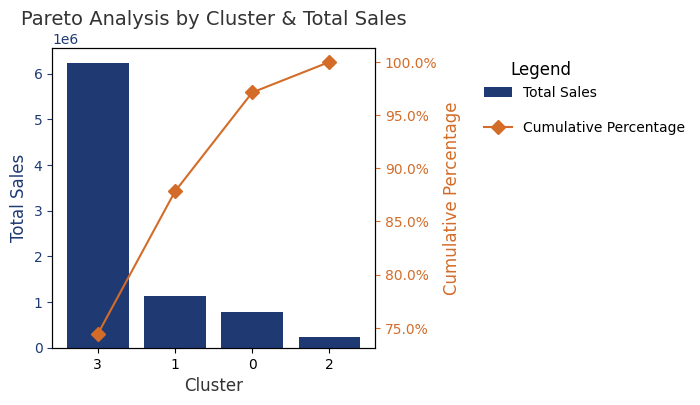

In [63]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# specify the width and height (in inches) using figsize
fig, ax = plt.subplots(figsize=(8,4))

# use dark blue for the bars and dark orange for the line
ax.bar(pareto_df["Cluster"], pareto_df["TotalSales"], color="#1f3a73")  # Dark blue
ax2 = ax.twinx()
ax2.plot(pareto_df["Cluster"], pareto_df["Cumulative Percentage"], color="#d36c28", marker="D", ms=7)  # Dark orange

# format the y-axis on the right to show percentage
ax2.yaxis.set_major_formatter(PercentFormatter())

# set tick colors
ax.tick_params(axis="y", colors="#1f3a73")  # Matching the bar color
ax2.tick_params(axis="y", colors="#d36c28")  # Matching the line color

# add labels and title
ax.set_xlabel('Cluster', fontsize=12, color="#333333")
ax.set_ylabel('Total Sales', fontsize=12, color="#1f3a73")
ax2.set_ylabel('Cumulative Percentage', fontsize=12, color="#d36c28")
plt.title('Pareto Analysis by Cluster & Total Sales', fontsize=14, color="#333333")

# add legends with adjusted position
ax.legend(["Total Sales"], loc='upper left', fontsize=10, frameon=False, title="Legend", title_fontsize=12, bbox_to_anchor=(1.3, 1))
ax2.legend(["Cumulative Percentage"], loc='upper left', fontsize=10, frameon=False, bbox_to_anchor=(1.3, 0.8))

# adjust layout to avoid overlap
plt.tight_layout()

# show the plot
plt.show()